# 问题一：出厂水浊度的影响因素与机器学习分析

本 notebook 从 `data/merged.xlsx` 读取合并后的水厂监测数据，以出厂水浊度 `NTU` 为因变量。读取后首先删除 `NTU` 缺失行，并对其余缺失值采用两种完整案例策略：

1. **方案 A（删除缺失特征）**：删除任何含缺失值的输入特征，保留全部目标有效行。
2. **方案 B（删除缺失行）**：保留全部输入特征，删除任一输入特征含缺失值的行。

两套数据分别执行相同的 PCA、Random Forest、XGBoost、变量重要性、SHAP、Pearson 与 Spearman 相关性分析，并在最后比较结果。模型按时间顺序划分训练集和测试集，只在训练段内进行时间序列交叉验证。


## 1. 环境与依赖

导入分析所需的库，设置随机种子和统一绘图风格。


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Songti SC", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"pandas: {pd.__version__}")
print(f"SHAP: {shap.__version__}")


pandas: 3.0.2
SHAP: 0.51.0


## 2. 读取数据并删除目标缺失行

合并 `DATE` 与 `TIME` 形成时间戳并排序。在主分析开始前删除 `NTU` 缺失行，此后的 `raw_df` 仅表示目标值有效的数据。这里只报告删除后的数据规模。


In [2]:
def locate_data_file():
    candidates = [
        Path.cwd() / "data" / "merged.xlsx",
        Path.cwd().parent / "data" / "merged.xlsx",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(f"未找到 merged.xlsx，已检查：\n{searched}")


TARGET = "NTU"
DATA_PATH = locate_data_file()
raw_df = pd.read_excel(DATA_PATH, sheet_name="Merged")

time_text = raw_df["TIME"].astype(str).str.split().str[-1]
raw_df["TIMESTAMP"] = pd.to_datetime(
    raw_df["DATE"].astype(str).str.split().str[0] + " " + time_text,
    errors="coerce",
)
raw_df = (
    raw_df.dropna(subset=[TARGET])
    .sort_values("TIMESTAMP")
    .reset_index(drop=True)
)

print(f"数据文件：{DATA_PATH}")
print(f"删除 NTU 缺失行后的数据规模：{raw_df.shape[0]:,} 行 × {raw_df.shape[1]} 列")
print(f"时间范围：{raw_df['TIMESTAMP'].min()} 至 {raw_df['TIMESTAMP'].max()}")
print(f"时间戳解析失败数：{raw_df['TIMESTAMP'].isna().sum()}")

data_audit = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_rate": raw_df.isna().mean(),
    "unique_count": raw_df.nunique(dropna=True),
}).sort_values("missing_rate", ascending=False)
display(raw_df.head())
display(data_audit.style.format({"missing_rate": "{:.2%}"}))


数据文件：/Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
删除 NTU 缺失行后的数据规模：5,124 行 × 19 列
时间范围：2025-01-01 07:00:00 至 2026-04-01 05:00:00
时间戳解析失败数：0


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW,TIMESTAMP
0,2025-01-01,07:00:00,6.22,2,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,NaN,0.04,2.0,42.6,2025-01-01 07:00:00
1,2025-01-01,09:00:00,6.34,2,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,NaN,0.04,2.0,42.6,2025-01-01 09:00:00
2,2025-01-01,11:00:00,6.17,2,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,NaN,0.04,2.0,42.7,2025-01-01 11:00:00
3,2025-01-01,13:00:00,5.99,2,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,NaN,0.04,2.0,42.3,2025-01-01 13:00:00
4,2025-01-01,15:00:00,5.83,2,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,NaN,0.04,2.0,42.5,2025-01-01 15:00:00


,dtype,missing_count,missing_rate,unique_count
F/RIDE,float64,4012,78.30%,16
R/W PUMP DUTY,object,1731,33.78%,8
CL2,float64,1707,33.31%,39
T/W PUMP DUTY,float64,1644,32.08%,3
ALUM,float64,1644,32.08%,5
R/W PH,float64,1644,32.08%,3
PH,float64,1644,32.08%,5
RIVER LEVEL,float64,7,0.14%,834
DATE,datetime64[us],0,0.00%,429
CLR,float64,0,0.00%,10


## 3. 构造两套分析数据

日期、时间、时间戳、备注、目标列和全空字段不作为输入特征。方案 A 删除在 `raw_df` 中出现任何缺失值的输入特征；方案 B 保留全部非全空输入特征，并删除任一输入特征缺失的行。两套数据均不进行插补。


In [3]:
NON_FEATURE_COLUMNS = {"DATE", "TIME", "TIMESTAMP", "REMARKS", TARGET}
all_empty_columns = set(raw_df.columns[raw_df.isna().all()])
candidate_features = [
    column
    for column in raw_df.columns
    if column not in NON_FEATURE_COLUMNS | all_empty_columns
]

scheme_a_features = [
    column for column in candidate_features
    if not raw_df[column].isna().any()
]
scheme_a_df = raw_df.copy()

scheme_b_features = candidate_features.copy()
scheme_b_df = raw_df.dropna(subset=scheme_b_features).copy()

dataset_summary = pd.DataFrame({
    "方案": ["A：删除缺失特征", "B：删除缺失行"],
    "样本数": [len(scheme_a_df), len(scheme_b_df)],
    "输入特征数": [len(scheme_a_features), len(scheme_b_features)],
    "删除的输入特征": [
        ", ".join(sorted(set(candidate_features) - set(scheme_a_features))),
        "无",
    ],
})
display(dataset_summary)
print("方案 A 输入特征：", scheme_a_features)
print("方案 B 输入特征：", scheme_b_features)

assert not scheme_a_df[scheme_a_features + [TARGET]].isna().any().any()
assert not scheme_b_df[scheme_b_features + [TARGET]].isna().any().any()


,方案,样本数,输入特征数,删除的输入特征
0,A：删除缺失特征,5124,7,"ALUM, CL2, F/RIDE, PH, R/W PH, R/W PUMP DUTY, ..."
1,B：删除缺失行,1046,15,无


方案 A 输入特征： ['R/W FLOW', 'R/W NTU', 'R/W CLR', 'FILT. NTU', 'C/W WELL LEVEL', 'CLR', 'T/W FLOW']
方案 B 输入特征： ['RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']


## 4. 共用分析函数

以下函数对任意一套完整数据执行完全相同的时间切分、PCA、模型调参、性能评价、变量重要性、SHAP 和相关性分析。两套方案采用相同随机种子、参数空间、4 折时间序列交叉验证和 80%/20% 时间顺序划分。


In [4]:
def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }


def transformed_feature_metadata(fitted_pipeline, numeric_features, categorical_features):
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    transformed_names = fitted_preprocessor.get_feature_names_out().tolist()
    source_names = list(numeric_features)
    if categorical_features:
        encoder = fitted_preprocessor.named_transformers_["categorical"]
        for column, categories in zip(categorical_features, encoder.categories_):
            source_names.extend([column] * len(categories))
    if len(transformed_names) != len(source_names):
        raise ValueError("转换后特征与原始字段映射长度不一致")
    return transformed_names, source_names


def aggregated_tree_importance(fitted_pipeline, numeric_features, categorical_features):
    transformed_names, source_names = transformed_feature_metadata(
        fitted_pipeline, numeric_features, categorical_features
    )
    detail = pd.DataFrame({
        "transformed_feature": transformed_names,
        "source_feature": source_names,
        "importance": fitted_pipeline.named_steps["model"].feature_importances_,
    })
    aggregated = (
        detail.groupby("source_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    return aggregated


def compute_shap_results(
    name,
    fitted_pipeline,
    X_source,
    numeric_features,
    categorical_features,
    max_samples=500,
):
    sample_positions = np.linspace(
        0, len(X_source) - 1, min(max_samples, len(X_source)), dtype=int
    )
    X_sample = X_source.iloc[sample_positions]
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    tree_model = fitted_pipeline.named_steps["model"]
    transformed_names, source_names = transformed_feature_metadata(
        fitted_pipeline, numeric_features, categorical_features
    )
    transformed_sample = fitted_preprocessor.transform(X_sample)
    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(transformed_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)
    global_detail = pd.DataFrame({
        "transformed_feature": transformed_names,
        "source_feature": source_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    global_aggregated = (
        global_detail.groupby("source_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )
    return {
        "name": name,
        "values": shap_values,
        "data": transformed_sample,
        "feature_names": transformed_names,
        "aggregated": global_aggregated,
    }


def target_correlations(matrix, target=TARGET):
    result = matrix[target].drop(index=target).dropna().to_frame("correlation")
    result["absolute_correlation"] = result["correlation"].abs()
    return result.sort_values("absolute_correlation", ascending=False)


In [5]:
def run_analysis(scheme_name, analysis_df, feature_columns):
    print("=" * 90)
    print(scheme_name)
    print("=" * 90)

    X = analysis_df[feature_columns].copy()
    y = analysis_df[TARGET].astype(float)
    timestamps = analysis_df["TIMESTAMP"]
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = [
        column for column in feature_columns if column not in numeric_features
    ]
    for column in categorical_features:
        X[column] = X[column].astype(str)

    split_index = int(len(analysis_df) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    time_train, time_test = timestamps.iloc[:split_index], timestamps.iloc[split_index:]

    transformers = []
    if numeric_features:
        transformers.append(("numeric", "passthrough", numeric_features))
    if categorical_features:
        transformers.append((
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ))
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

    print(f"样本数：{len(analysis_df):,}；输入特征数：{len(feature_columns)}")
    print(f"连续特征（{len(numeric_features)} 个）：{numeric_features}")
    print(f"类别特征（{len(categorical_features)} 个）：{categorical_features}")
    print(f"训练集：{len(X_train):,} 条，{time_train.min()} 至 {time_train.max()}")
    print(f"测试集：{len(X_test):,} 条，{time_test.min()} 至 {time_test.max()}")
    assert time_train.max() < time_test.min()
    assert not X.isna().any().any()

    # PCA
    pca_features = [
        column for column in numeric_features
        if analysis_df[column].nunique(dropna=True) > 1
    ]
    pca_input = StandardScaler().fit_transform(analysis_df[pca_features])
    pca = PCA()
    pca_scores = pca.fit_transform(pca_input)
    explained = pd.DataFrame({
        "component": [f"PC{i + 1}" for i in range(pca.n_components_)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_),
    })
    print("\nPCA 解释方差：")
    display(explained.style.format({
        "explained_variance_ratio": "{:.2%}",
        "cumulative_variance_ratio": "{:.2%}",
    }))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].bar(explained["component"], explained["explained_variance_ratio"])
    axes[0].plot(
        explained["component"],
        explained["cumulative_variance_ratio"],
        color="tab:red",
        marker="o",
        label="累计解释方差",
    )
    axes[0].set_title(f"{scheme_name}：PCA 碎石图")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].legend()
    scatter = axes[1].scatter(
        pca_scores[:, 0],
        pca_scores[:, 1],
        c=analysis_df[TARGET],
        cmap="viridis",
        alpha=0.55,
        s=16,
    )
    axes[1].set_title(f"{scheme_name}：前两个主成分")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    fig.colorbar(scatter, ax=axes[1], label="NTU")
    plt.tight_layout()
    plt.show()

    loading_count = min(5, pca.n_components_)
    loadings = pd.DataFrame(
        pca.components_[:loading_count].T,
        index=pca_features,
        columns=[f"PC{i + 1}" for i in range(loading_count)],
    )
    display(loadings.style.background_gradient(cmap="coolwarm", axis=None).format("{:.3f}"))
    for component in loadings.columns:
        top_variables = loadings[component].abs().nlargest(5).index
        print(f"{component} 绝对载荷最高变量：{', '.join(top_variables)}")

    time_cv = TimeSeriesSplit(n_splits=4)
    model_specs = {
        "Random Forest": (
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            {
                "model__n_estimators": [300, 500, 700],
                "model__max_depth": [None, 8, 14, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
                "model__max_features": ["sqrt", 0.7, 1.0],
            },
        ),
        "XGBoost": (
            XGBRegressor(
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                tree_method="hist",
            ),
            {
                "model__n_estimators": [300, 500, 700],
                "model__learning_rate": [0.02, 0.05, 0.1],
                "model__max_depth": [3, 5, 7],
                "model__min_child_weight": [1, 3, 6],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
                "model__reg_lambda": [1.0, 5.0, 10.0],
            },
        ),
    }
    fitted_models = {}
    predictions = {}
    metrics = {}

    for model_name, (estimator, params) in model_specs.items():
        print(f"\n{model_name} 参数搜索")
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", estimator),
        ])
        search = RandomizedSearchCV(
            pipeline,
            param_distributions=params,
            n_iter=15,
            scoring="neg_root_mean_squared_error",
            cv=time_cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
            verbose=1,
        )
        search.fit(X_train, y_train)
        fitted_models[model_name] = search.best_estimator_
        predictions[model_name] = search.best_estimator_.predict(X_test)
        metrics[model_name] = regression_metrics(y_test, predictions[model_name])
        print("最优参数：", search.best_params_)

        plt.figure(figsize=(13, 5))
        plt.plot(time_test, y_test, label="实际 NTU", linewidth=1.2)
        plt.plot(
            time_test,
            predictions[model_name],
            label=f"{model_name} 预测",
            linewidth=1.1,
        )
        plt.title(f"{scheme_name} - {model_name}：实际值与预测值")
        plt.xlabel("时间")
        plt.ylabel("NTU")
        plt.legend()
        plt.tight_layout()
        plt.show()

    metrics_table = pd.DataFrame(metrics).T.sort_values("RMSE")
    print("\n模型性能比较：")
    display(metrics_table.style.format("{:.4f}").highlight_min(
        subset=["MAE", "RMSE"], color="#c6efce"
    ).highlight_max(subset=["R2"], color="#c6efce"))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    for axis, model_name in zip(axes, model_specs):
        model_predictions = predictions[model_name]
        axis.scatter(y_test, model_predictions, alpha=0.5, s=18)
        limits = [
            min(y_test.min(), model_predictions.min()),
            max(y_test.max(), model_predictions.max()),
        ]
        axis.plot(limits, limits, "--", color="tab:red")
        axis.set_title(f"{scheme_name} - {model_name}")
        axis.set_xlabel("实际 NTU")
        axis.set_ylabel("预测 NTU")
    plt.tight_layout()
    plt.show()

    importance_tables = {}
    for model_name, fitted_model in fitted_models.items():
        importance_tables[model_name] = aggregated_tree_importance(
            fitted_model, numeric_features, categorical_features
        )
    print("\n原始变量重要性：")
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for axis, model_name in zip(axes, model_specs):
        table = importance_tables[model_name]
        display(table.head(15).style.format({"importance": "{:.4f}"}))
        top = table.head(15).sort_values("importance")
        axis.barh(top["source_feature"], top["importance"])
        axis.set_title(f"{scheme_name} - {model_name} 变量重要性")
    plt.tight_layout()
    plt.show()

    shap_results = {}
    for model_name, fitted_model in fitted_models.items():
        shap_results[model_name] = compute_shap_results(
            model_name,
            fitted_model,
            X_test,
            numeric_features,
            categorical_features,
        )
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    for axis, model_name in zip(axes, model_specs):
        result = shap_results[model_name]
        top = result["aggregated"].head(15).sort_values("mean_abs_shap")
        axis.barh(top["source_feature"], top["mean_abs_shap"])
        axis.set_title(f"{scheme_name} - {model_name} 聚合 SHAP")
    plt.tight_layout()
    plt.show()

    for model_name in model_specs:
        result = shap_results[model_name]
        shap.summary_plot(
            result["values"],
            result["data"],
            feature_names=result["feature_names"],
            plot_type="dot",
            max_display=18,
            plot_size=(12, 8),
            color_bar_label="Feature value",
            show=False,
        )
        plt.title(f"{scheme_name} - {model_name} SHAP 分布")
        plt.axvline(0, color="gray", linewidth=1, alpha=0.8)
        plt.tight_layout()
        plt.show()
        display(result["aggregated"].head(15).style.format({"mean_abs_shap": "{:.4f}"}))

    correlation_columns = [
        column for column in feature_columns + [TARGET]
        if pd.api.types.is_numeric_dtype(analysis_df[column])
        and analysis_df[column].nunique(dropna=True) > 1
    ]
    correlation_data = analysis_df[correlation_columns]
    pearson_corr = correlation_data.corr(method="pearson", min_periods=30)
    spearman_corr = correlation_data.corr(method="spearman", min_periods=30)
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    for axis, title, matrix in [
        (axes[0], "Pearson 相关系数", pearson_corr),
        (axes[1], "Spearman 相关系数", spearman_corr),
    ]:
        sns.heatmap(
            matrix,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.3,
            cbar_kws={"shrink": 0.75},
            ax=axis,
        )
        axis.set_title(f"{scheme_name} - {title}")
    plt.tight_layout()
    plt.show()

    pearson_target = target_correlations(pearson_corr)
    spearman_target = target_correlations(spearman_corr)
    print("与 NTU 的 Pearson 相关性：")
    display(pearson_target.style.format("{:.4f}"))
    print("与 NTU 的 Spearman 相关性：")
    display(spearman_target.style.format("{:.4f}"))

    return {
        "scheme": scheme_name,
        "n_rows": len(analysis_df),
        "n_features": len(feature_columns),
        "metrics": metrics_table,
        "importance": importance_tables,
        "shap": shap_results,
        "pearson_target": pearson_target,
        "spearman_target": spearman_target,
    }


## 5. 方案 A：删除含缺失值的输入特征

以删除 `NTU` 缺失行后的 `raw_df` 为起点，整体删除任何仍含缺失值的输入特征，然后执行完整分析。


方案 A：删除缺失特征
样本数：5,124；输入特征数：7
连续特征（7 个）：['R/W FLOW', 'R/W NTU', 'R/W CLR', 'FILT. NTU', 'C/W WELL LEVEL', 'CLR', 'T/W FLOW']
类别特征（0 个）：[]
训练集：4,099 条，2025-01-01 07:00:00 至 2025-12-08 19:00:00
测试集：1,025 条，2025-12-08 21:00:00 至 2026-04-01 05:00:00

PCA 解释方差：


,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,29.66%,29.66%
1,PC2,23.85%,53.50%
2,PC3,15.54%,69.04%
3,PC4,14.14%,83.18%
4,PC5,10.99%,94.17%
5,PC6,3.57%,97.74%
6,PC7,2.26%,100.00%


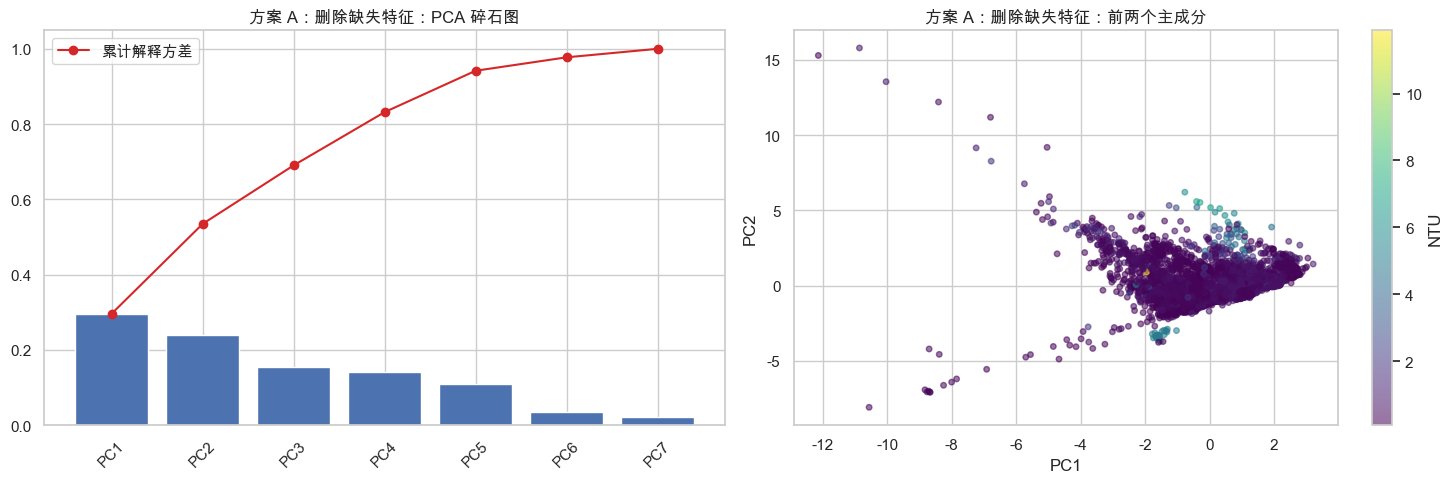

,PC1,PC2,PC3,PC4,PC5
R/W FLOW,0.551,0.394,-0.057,-0.055,-0.183
R/W NTU,-0.426,0.527,0.115,-0.014,-0.156
R/W CLR,-0.429,0.521,0.130,0.001,-0.176
FILT. NTU,-0.064,0.304,-0.637,-0.250,0.660
C/W WELL LEVEL,0.161,0.158,0.738,-0.058,0.633
CLR,0.051,0.141,-0.124,0.963,0.185
T/W FLOW,0.546,0.399,-0.031,-0.056,-0.203


PC1 绝对载荷最高变量：R/W FLOW, T/W FLOW, R/W CLR, R/W NTU, C/W WELL LEVEL
PC2 绝对载荷最高变量：R/W NTU, R/W CLR, T/W FLOW, R/W FLOW, FILT. NTU
PC3 绝对载荷最高变量：C/W WELL LEVEL, FILT. NTU, R/W CLR, CLR, R/W NTU
PC4 绝对载荷最高变量：CLR, FILT. NTU, C/W WELL LEVEL, T/W FLOW, R/W FLOW
PC5 绝对载荷最高变量：FILT. NTU, C/W WELL LEVEL, T/W FLOW, CLR, R/W FLOW

Random Forest 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 8}


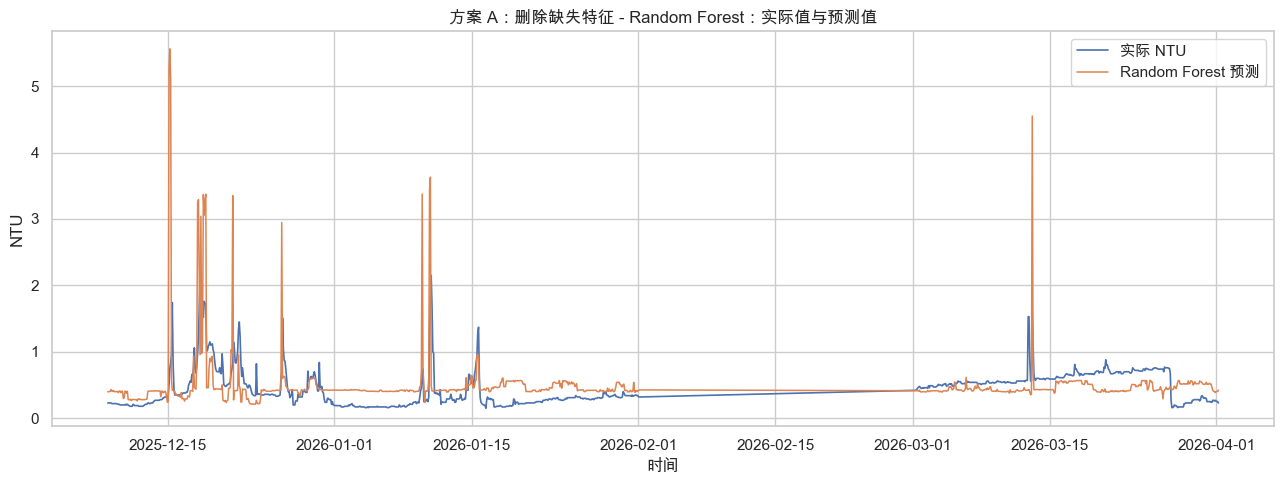


XGBoost 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__subsample': 0.85, 'model__reg_lambda': 5.0, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.85}


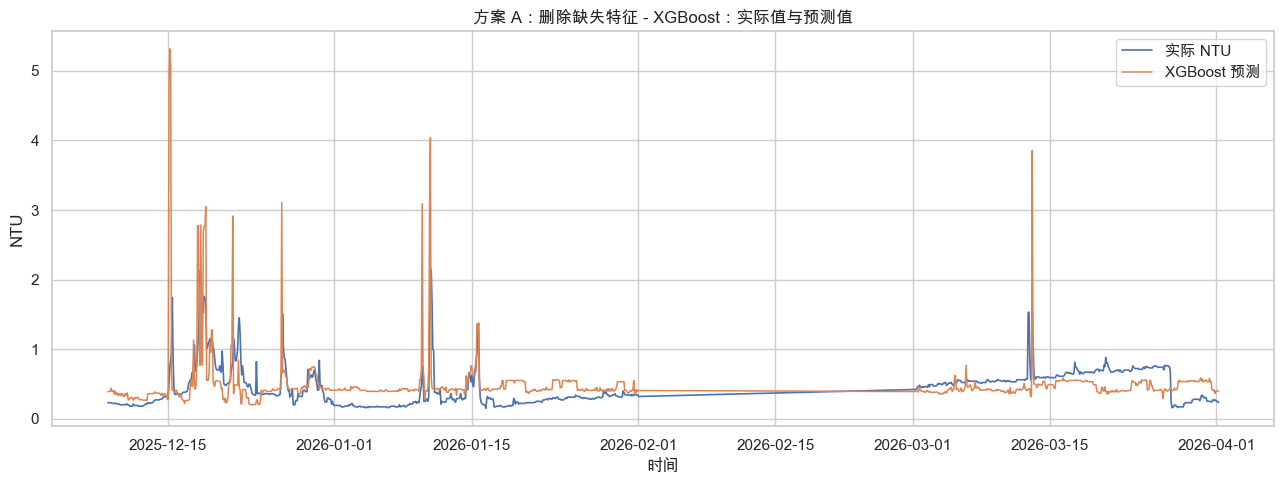


模型性能比较：


,MAE,RMSE,R2
XGBoost,0.2164,0.3878,-0.9237
Random Forest,0.2247,0.4157,-1.2101


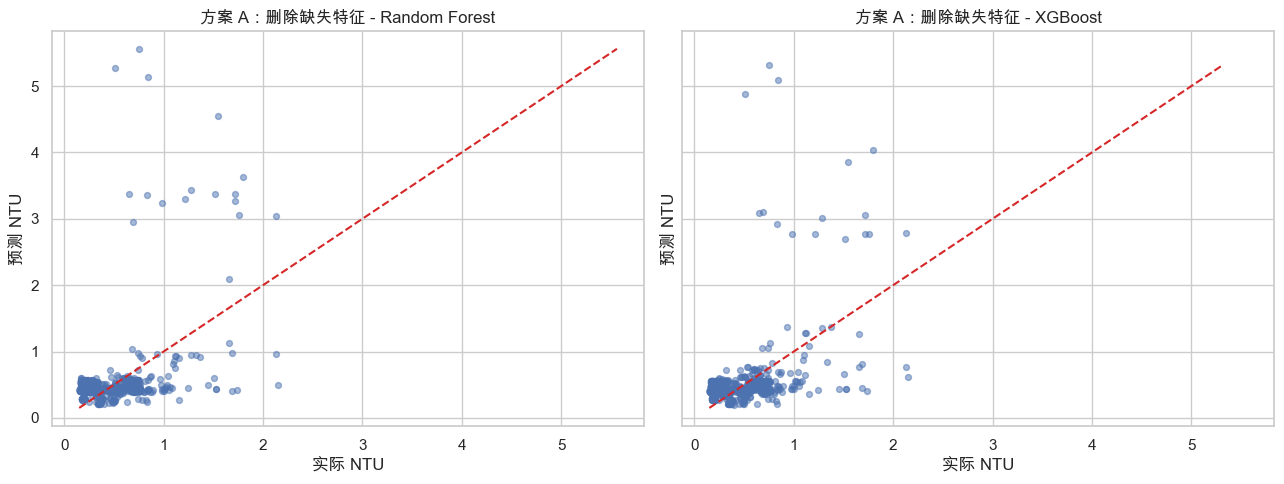


原始变量重要性：


,source_feature,importance
2,FILT. NTU,0.5874
1,CLR,0.2862
6,T/W FLOW,0.0334
4,R/W FLOW,0.0284
3,R/W CLR,0.0261
0,C/W WELL LEVEL,0.0196
5,R/W NTU,0.0189


,source_feature,importance
1,CLR,0.5156
2,FILT. NTU,0.3097
4,R/W FLOW,0.0415
5,R/W NTU,0.0374
6,T/W FLOW,0.0365
3,R/W CLR,0.0326
0,C/W WELL LEVEL,0.0266


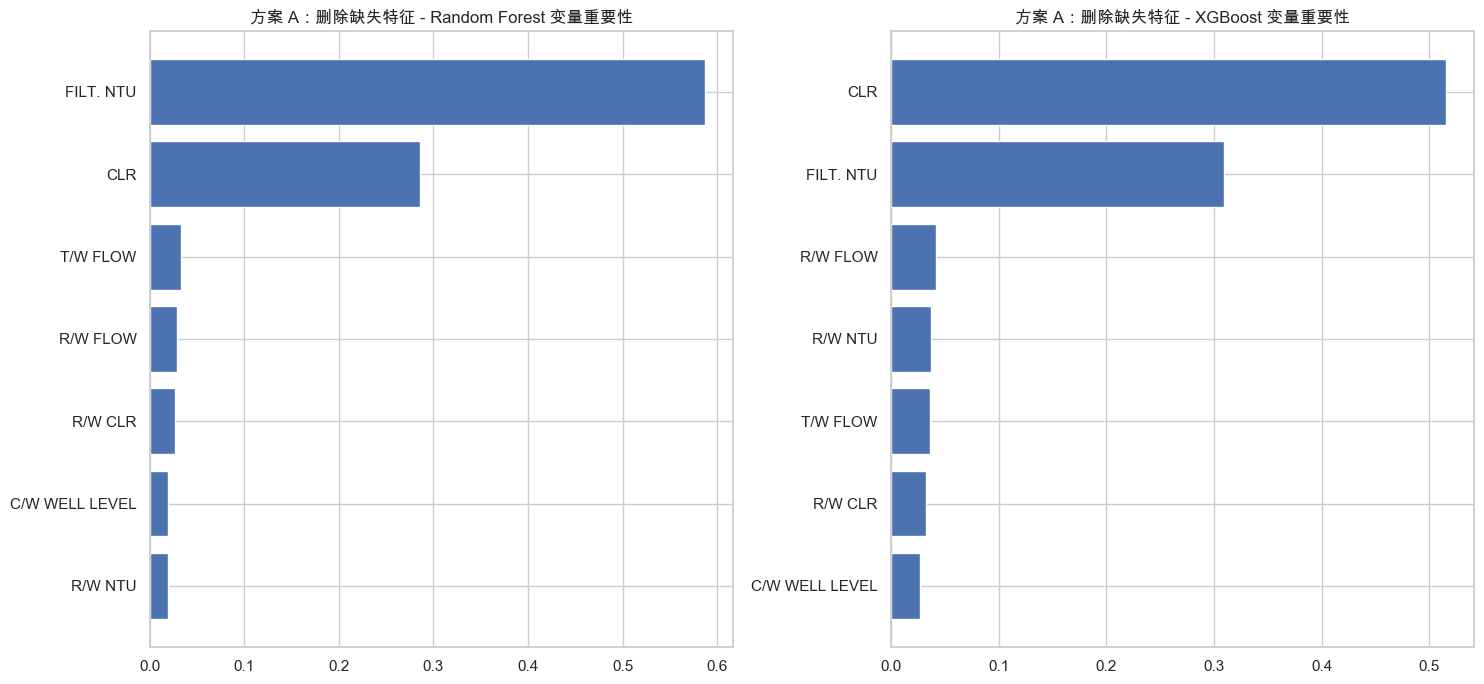

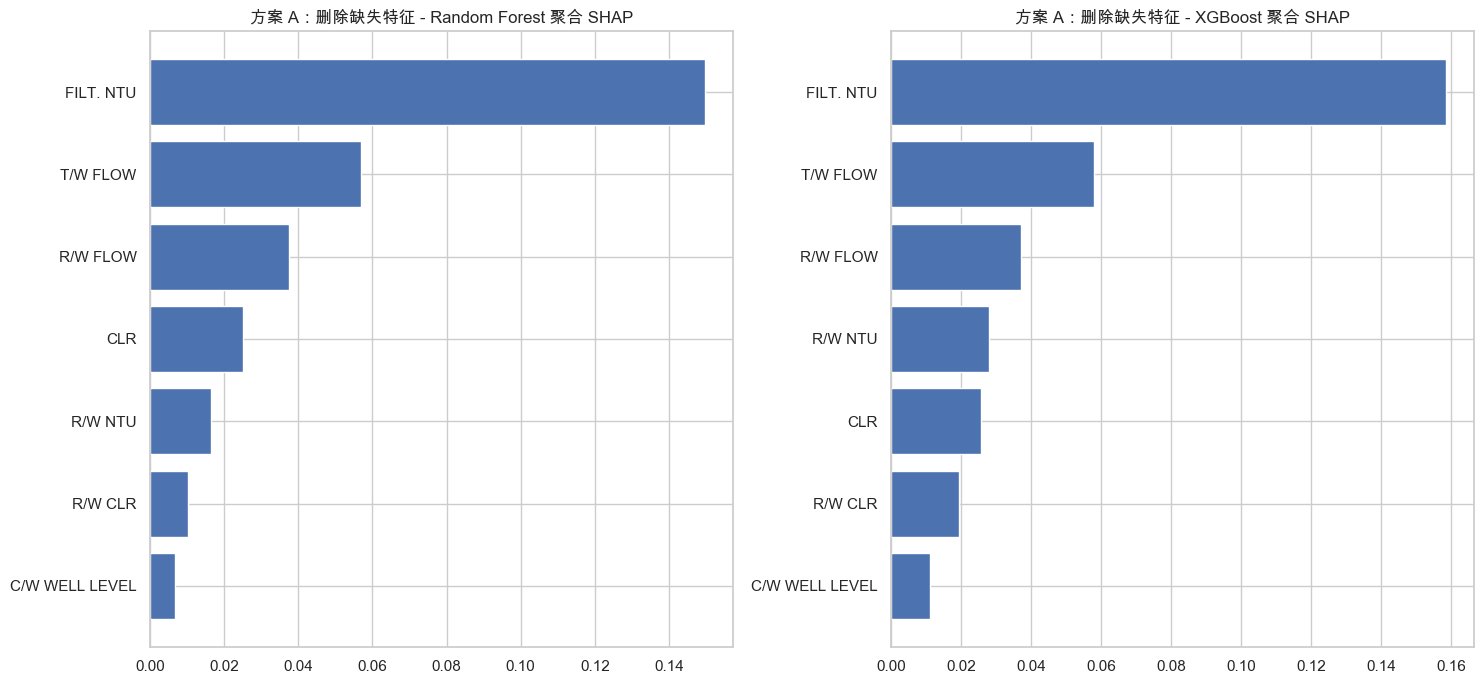

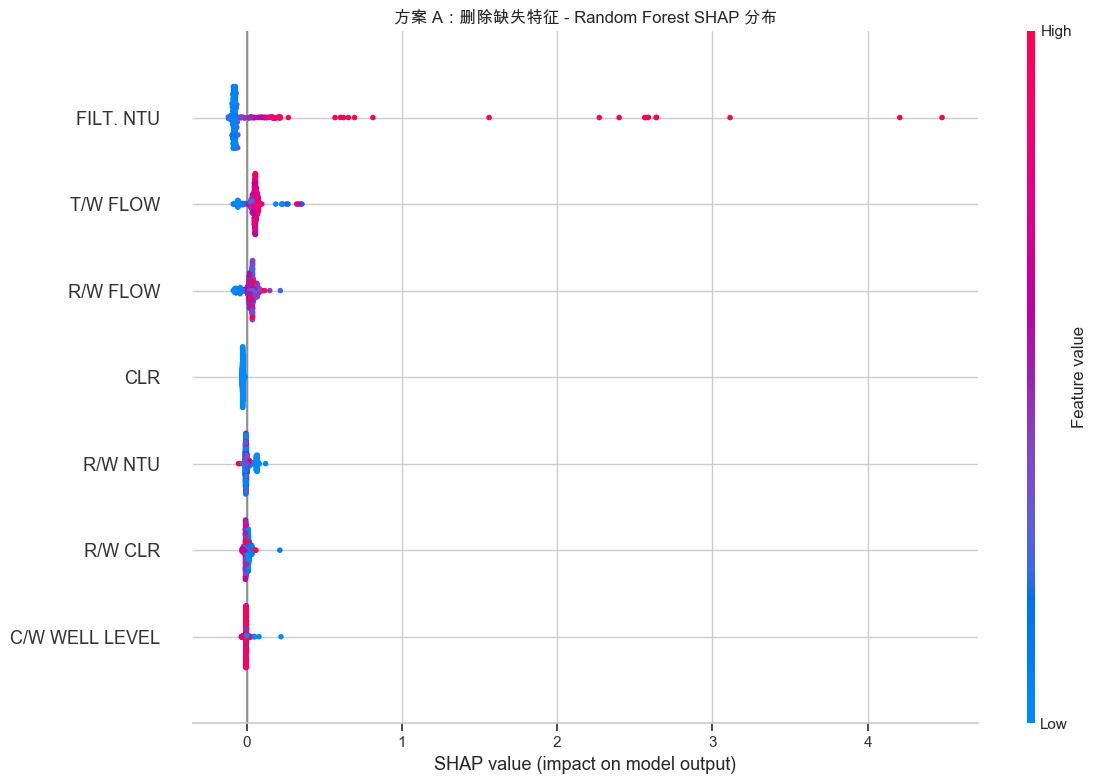

,source_feature,mean_abs_shap
2,FILT. NTU,0.1498
6,T/W FLOW,0.0568
4,R/W FLOW,0.0376
1,CLR,0.0250
5,R/W NTU,0.0164
3,R/W CLR,0.0104
0,C/W WELL LEVEL,0.0067


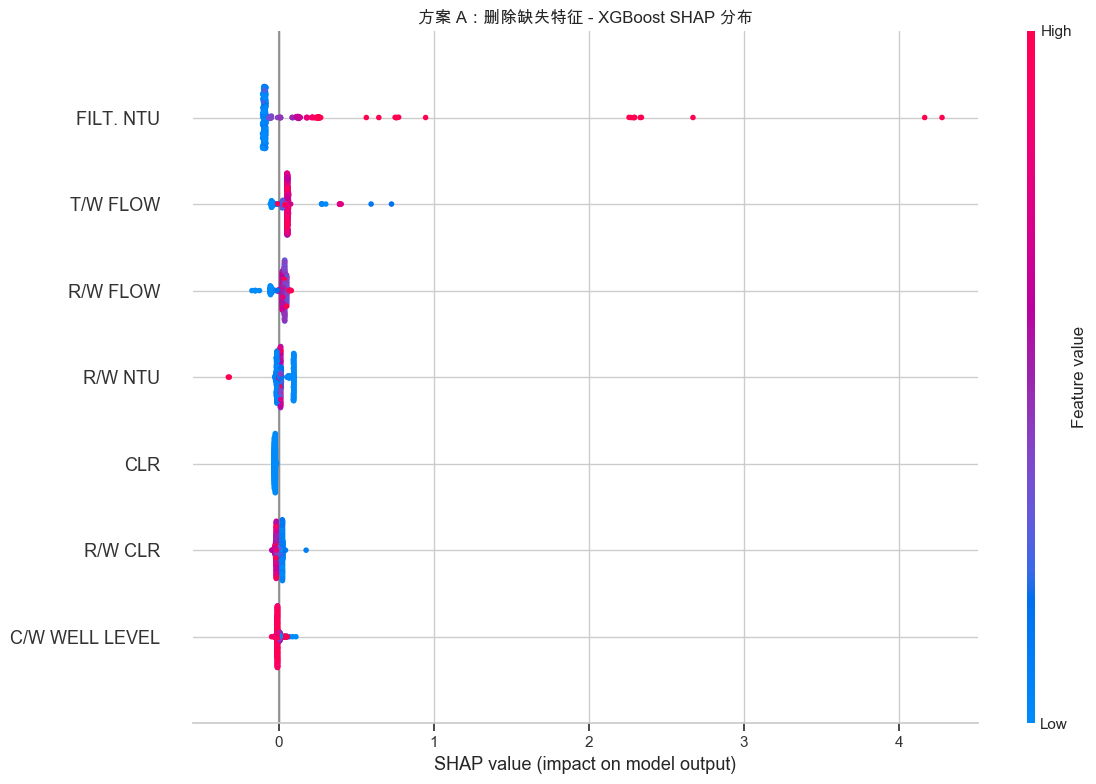

,source_feature,mean_abs_shap
2,FILT. NTU,0.1585
6,T/W FLOW,0.0579
4,R/W FLOW,0.0371
5,R/W NTU,0.0280
1,CLR,0.0258
3,R/W CLR,0.0194
0,C/W WELL LEVEL,0.0112


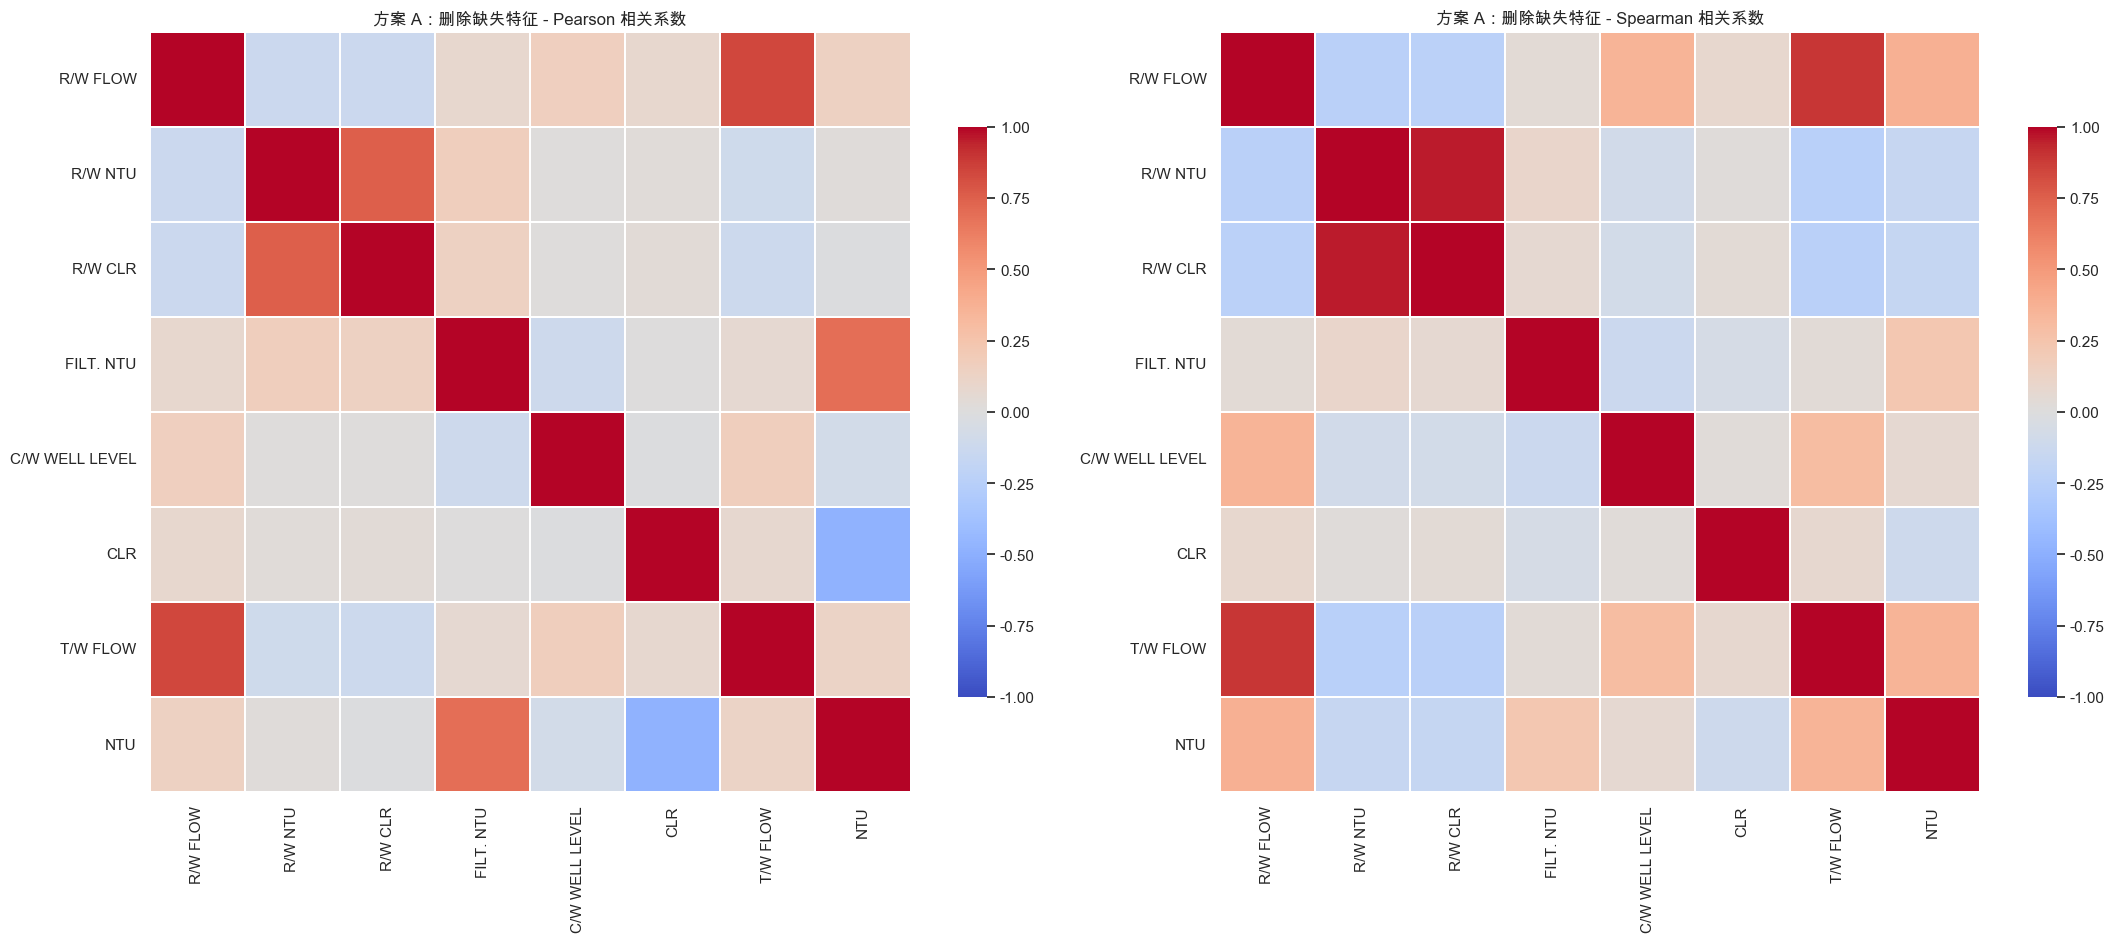

与 NTU 的 Pearson 相关性：


,correlation,absolute_correlation
FILT. NTU,0.6947,0.6947
CLR,-0.4827,0.4827
R/W FLOW,0.1409,0.1409
T/W FLOW,0.1183,0.1183
C/W WELL LEVEL,-0.0783,0.0783
R/W NTU,0.0232,0.0232
R/W CLR,-0.0121,0.0121


与 NTU 的 Spearman 相关性：


,correlation,absolute_correlation
R/W FLOW,0.3785,0.3785
T/W FLOW,0.3523,0.3523
FILT. NTU,0.2297,0.2297
R/W CLR,-0.1690,0.1690
R/W NTU,-0.1570,0.1570
CLR,-0.1100,0.1100
C/W WELL LEVEL,0.0667,0.0667


In [6]:
scheme_a_results = run_analysis(
    "方案 A：删除缺失特征",
    scheme_a_df,
    scheme_a_features,
)


## 6. 方案 B：保留全部输入特征并删除缺失行

保留包括 `F/RIDE` 在内的全部非全空输入特征，删除任一输入特征缺失的行，然后执行与方案 A 完全相同的分析。


方案 B：删除缺失行
样本数：1,046；输入特征数：15
连续特征（14 个）：['RIVER LEVEL', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
类别特征（1 个）：['R/W PUMP DUTY']
训练集：836 条，2025-10-30 15:00:00 至 2026-01-14 17:00:00
测试集：210 条，2026-01-14 19:00:00 至 2026-02-01 05:00:00

PCA 解释方差：


,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,27.27%,27.27%
1,PC2,17.20%,44.47%
2,PC3,9.62%,54.09%
3,PC4,8.66%,62.76%
4,PC5,7.90%,70.65%
5,PC6,7.39%,78.04%
6,PC7,6.34%,84.38%
7,PC8,5.79%,90.18%
8,PC9,4.81%,94.98%
9,PC10,2.81%,97.80%


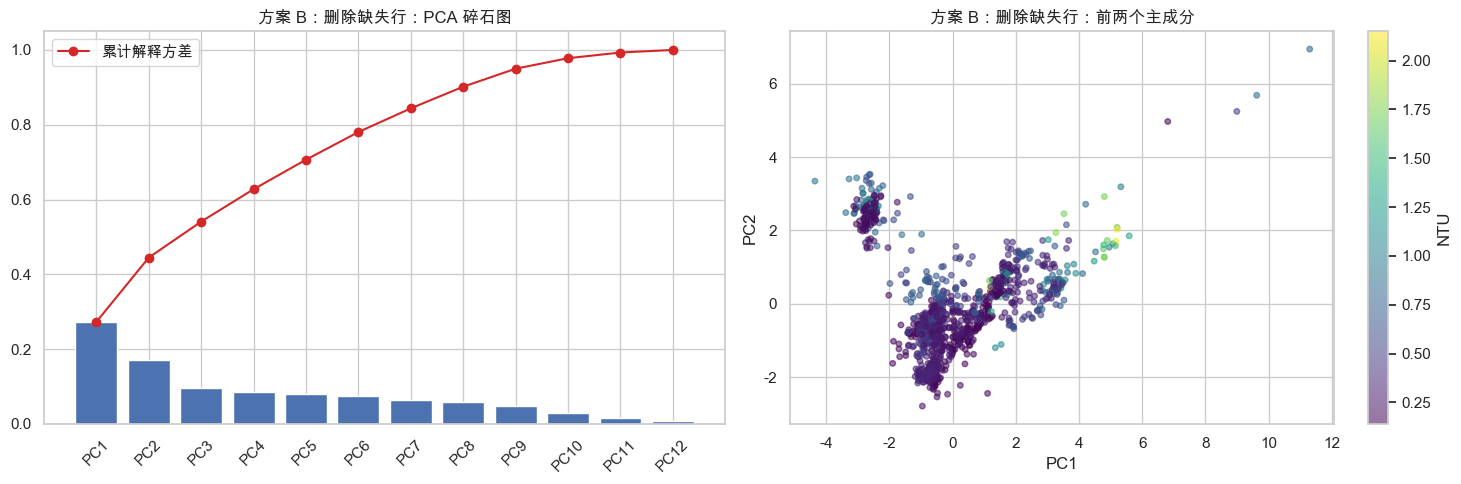

,PC1,PC2,PC3,PC4,PC5
RIVER LEVEL,0.178,0.285,-0.399,0.177,-0.071
R/W FLOW,-0.433,0.266,-0.003,0.018,0.135
R/W NTU,0.462,0.262,0.023,-0.012,0.079
R/W CLR,0.322,0.304,0.015,0.031,0.361
FILT. NTU,0.328,0.191,0.005,-0.026,0.117
C/W WELL LEVEL,-0.083,-0.163,0.506,0.357,0.647
PH,0.019,0.046,-0.430,0.657,0.021
CL2,-0.209,-0.328,-0.275,-0.174,0.032
F/RIDE,-0.063,-0.013,-0.494,-0.469,0.619
ALUM,-0.068,-0.357,-0.279,0.387,0.136


PC1 绝对载荷最高变量：R/W NTU, T/W FLOW, R/W FLOW, FILT. NTU, T/W PUMP DUTY
PC2 绝对载荷最高变量：T/W PUMP DUTY, T/W FLOW, ALUM, CL2, R/W CLR
PC3 绝对载荷最高变量：C/W WELL LEVEL, F/RIDE, PH, RIVER LEVEL, ALUM
PC4 绝对载荷最高变量：PH, F/RIDE, ALUM, C/W WELL LEVEL, RIVER LEVEL
PC5 绝对载荷最高变量：C/W WELL LEVEL, F/RIDE, R/W CLR, ALUM, R/W FLOW

Random Forest 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 14}


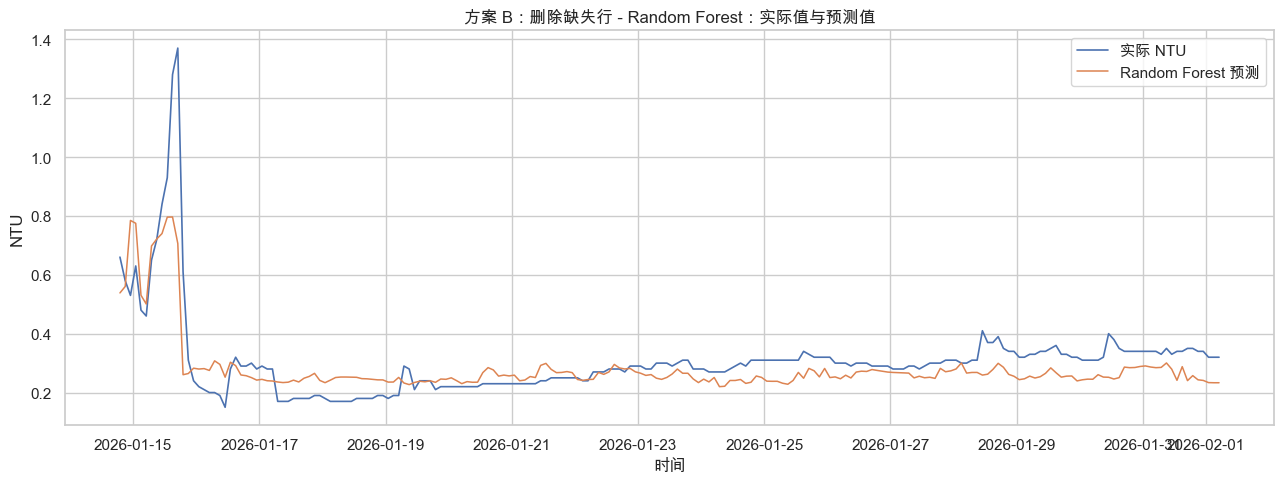


XGBoost 参数搜索
Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__subsample': 1.0, 'model__reg_lambda': 5.0, 'model__n_estimators': 700, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.85}


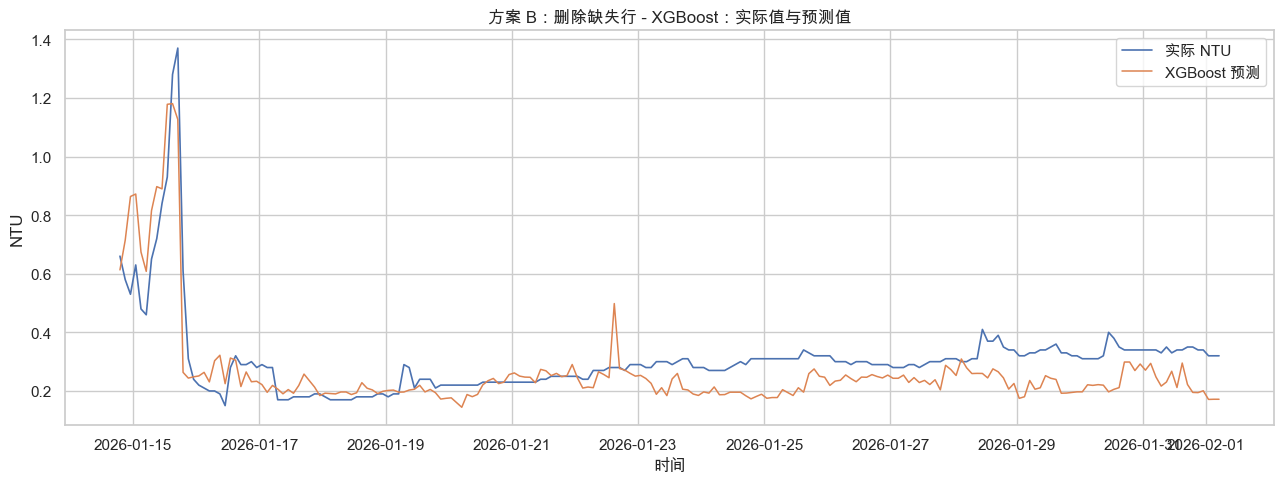


模型性能比较：


,MAE,RMSE,R2
Random Forest,0.0581,0.0868,0.6335
XGBoost,0.0733,0.0934,0.5755


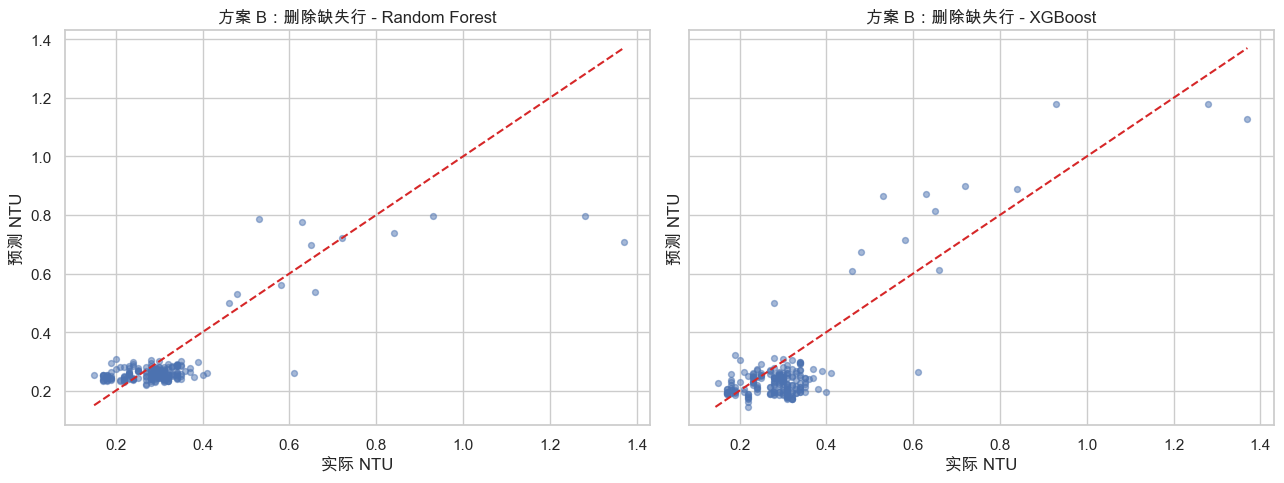


原始变量重要性：


,source_feature,importance
5,FILT. NTU,0.2291
12,RIVER LEVEL,0.1665
8,R/W FLOW,0.1392
13,T/W FLOW,0.1186
9,R/W NTU,0.1104
7,R/W CLR,0.0526
1,C/W WELL LEVEL,0.0405
0,ALUM,0.0380
11,R/W PUMP DUTY,0.0357
2,CL2,0.0350


,source_feature,importance
0,ALUM,0.1956
5,FILT. NTU,0.1787
14,T/W PUMP DUTY,0.1612
11,R/W PUMP DUTY,0.1420
2,CL2,0.0838
12,RIVER LEVEL,0.0524
13,T/W FLOW,0.0513
9,R/W NTU,0.0399
8,R/W FLOW,0.0369
4,F/RIDE,0.0256


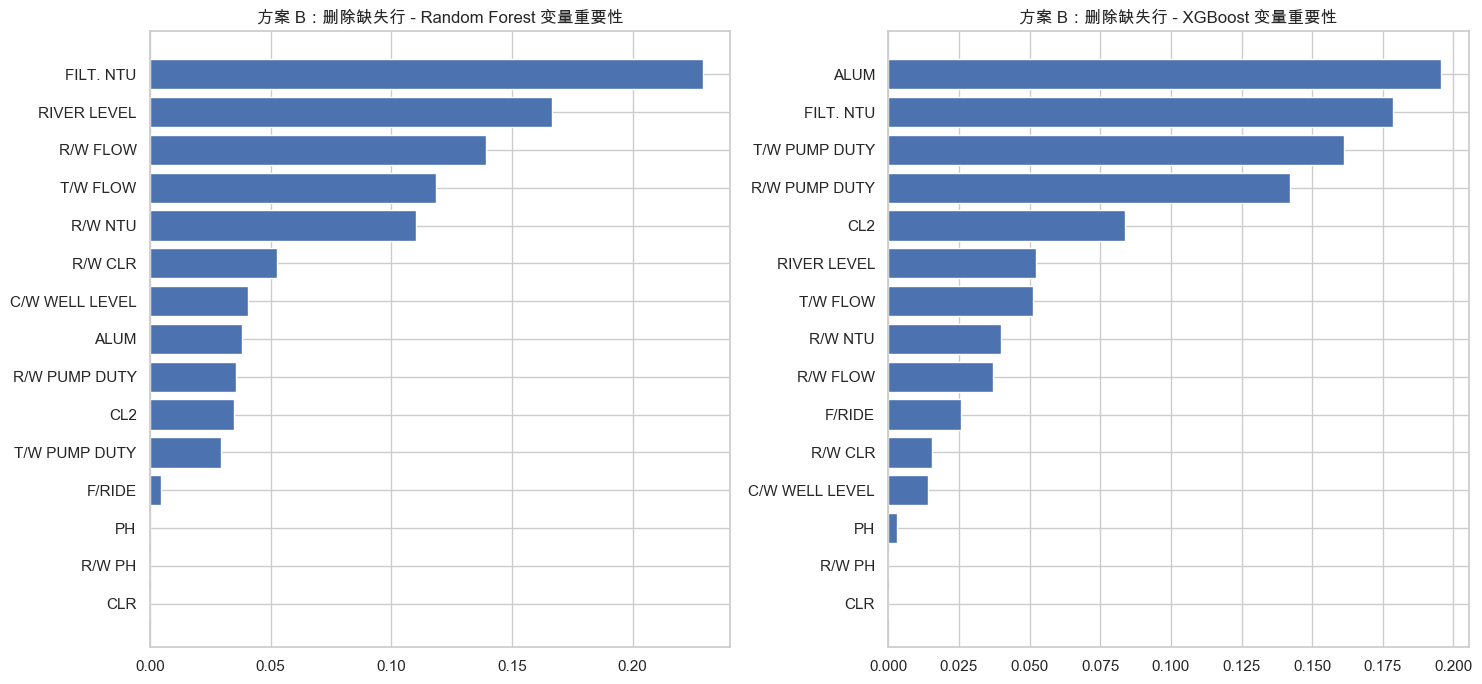

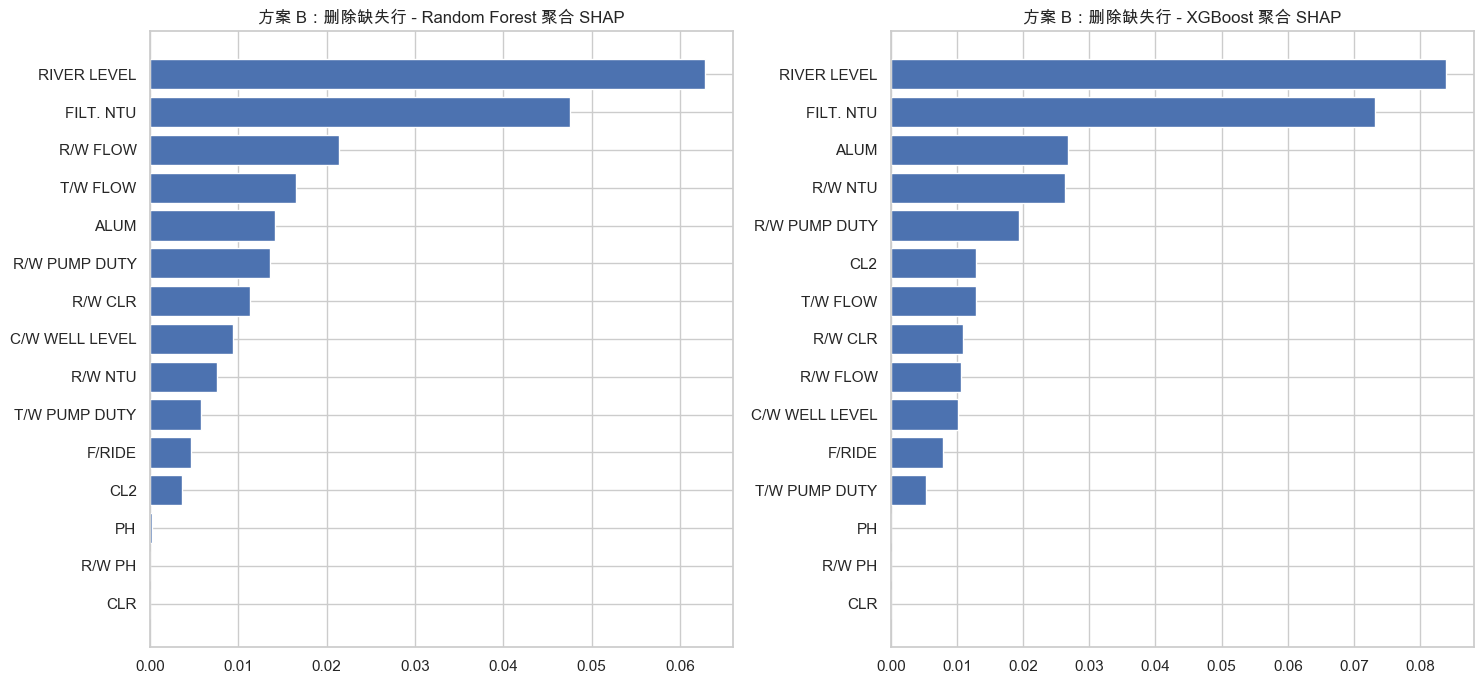

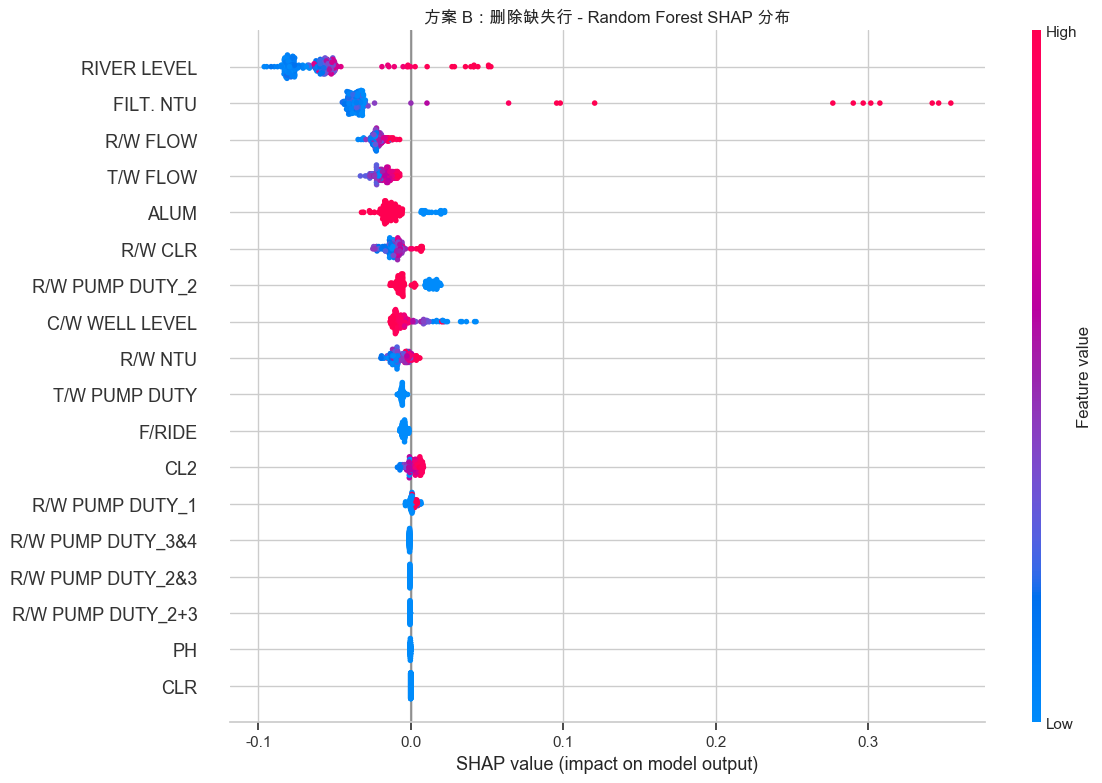

,source_feature,mean_abs_shap
12,RIVER LEVEL,0.0629
5,FILT. NTU,0.0475
8,R/W FLOW,0.0214
13,T/W FLOW,0.0166
0,ALUM,0.0142
11,R/W PUMP DUTY,0.0136
7,R/W CLR,0.0113
1,C/W WELL LEVEL,0.0094
9,R/W NTU,0.0075
14,T/W PUMP DUTY,0.0057


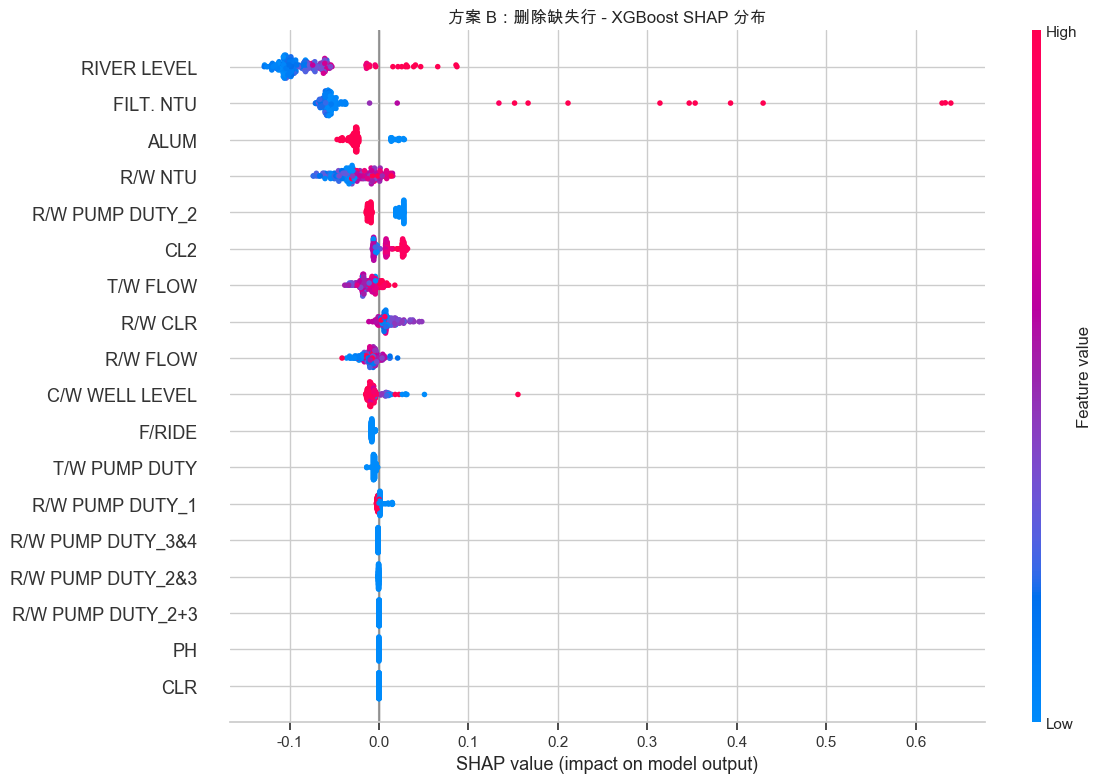

,source_feature,mean_abs_shap
12,RIVER LEVEL,0.0840
5,FILT. NTU,0.0732
0,ALUM,0.0267
9,R/W NTU,0.0263
11,R/W PUMP DUTY,0.0194
2,CL2,0.0129
13,T/W FLOW,0.0128
7,R/W CLR,0.0110
8,R/W FLOW,0.0106
1,C/W WELL LEVEL,0.0102


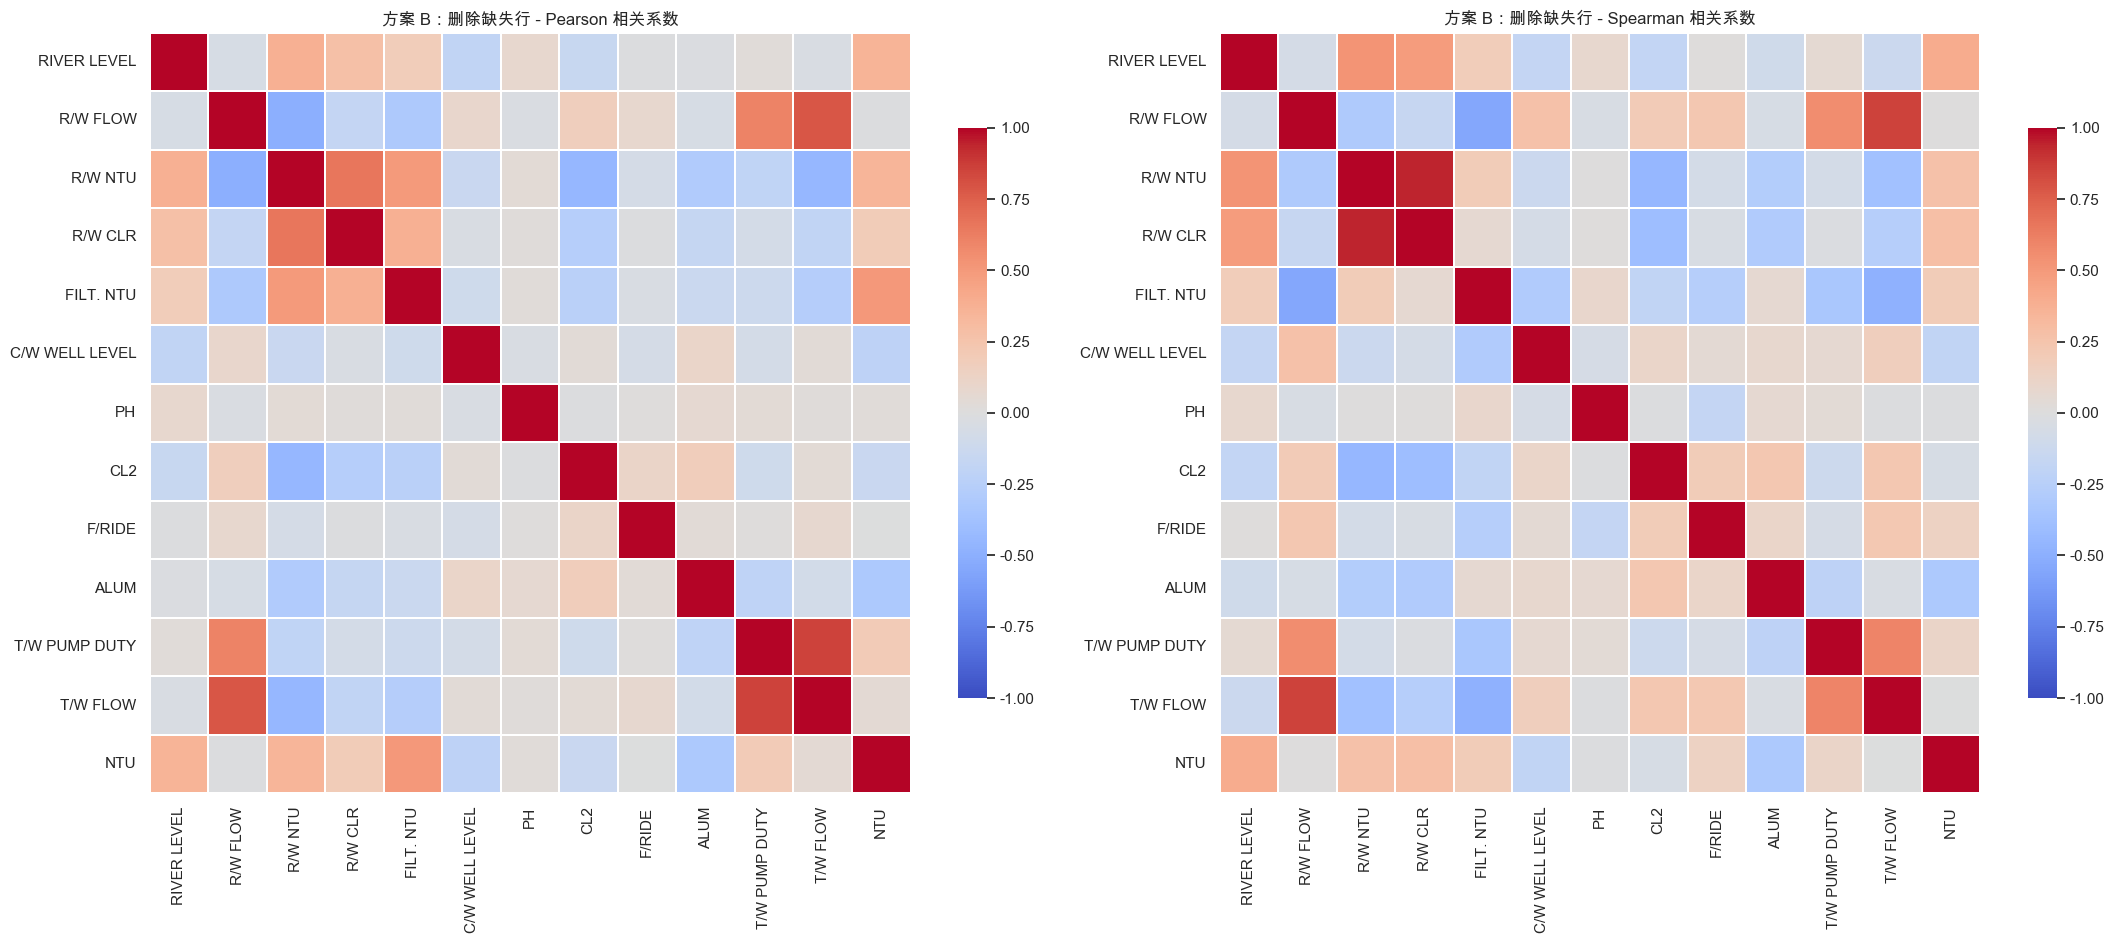

与 NTU 的 Pearson 相关性：


,correlation,absolute_correlation
FILT. NTU,0.5063,0.5063
RIVER LEVEL,0.3529,0.3529
R/W NTU,0.3464,0.3464
ALUM,-0.3159,0.3159
C/W WELL LEVEL,-0.2119,0.2119
T/W PUMP DUTY,0.1967,0.1967
R/W CLR,0.1920,0.1920
CL2,-0.1446,0.1446
T/W FLOW,0.0525,0.0525
PH,0.0269,0.0269


与 NTU 的 Spearman 相关性：


,correlation,absolute_correlation
RIVER LEVEL,0.4024,0.4024
ALUM,-0.3163,0.3163
R/W CLR,0.2827,0.2827
R/W NTU,0.2699,0.2699
C/W WELL LEVEL,-0.1909,0.1909
FILT. NTU,0.1904,0.1904
F/RIDE,0.1393,0.1393
T/W PUMP DUTY,0.1122,0.1122
CL2,-0.0546,0.0546
PH,-0.0112,0.0112


In [7]:
scheme_b_results = run_analysis(
    "方案 B：删除缺失行",
    scheme_b_df,
    scheme_b_features,
)


## 7. 两套方案对比

汇总两套数据的样本数、特征数、Random Forest 与 XGBoost 测试集指标，以及各解释方法排名靠前的变量。由于两套方案的样本时间范围和测试集不同，指标反映的是各自数据处理策略下的预测表现。


In [8]:
comparison_rows = []
for result in [scheme_a_results, scheme_b_results]:
    for model_name, row in result["metrics"].iterrows():
        comparison_rows.append({
            "方案": result["scheme"],
            "样本数": result["n_rows"],
            "输入特征数": result["n_features"],
            "模型": model_name,
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "R2": row["R2"],
        })

model_comparison = pd.DataFrame(comparison_rows).sort_values(["RMSE", "方案"])
display(model_comparison.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R2": "{:.4f}",
}).highlight_min(subset=["MAE", "RMSE"], color="#c6efce").highlight_max(
    subset=["R2"], color="#c6efce"
))

summary_rows = []
for result in [scheme_a_results, scheme_b_results]:
    best_model = result["metrics"]["RMSE"].idxmin()
    summary_rows.append({
        "方案": result["scheme"],
        "最佳模型": best_model,
        "最佳 RMSE": result["metrics"].loc[best_model, "RMSE"],
        "RF 重要性前三": ", ".join(
            result["importance"]["Random Forest"].head(3)["source_feature"]
        ),
        "XGB 重要性前三": ", ".join(
            result["importance"]["XGBoost"].head(3)["source_feature"]
        ),
        "RF SHAP 前三": ", ".join(
            result["shap"]["Random Forest"]["aggregated"].head(3)["source_feature"]
        ),
        "XGB SHAP 前三": ", ".join(
            result["shap"]["XGBoost"]["aggregated"].head(3)["source_feature"]
        ),
        "Pearson 前三": ", ".join(result["pearson_target"].head(3).index),
        "Spearman 前三": ", ".join(result["spearman_target"].head(3).index),
    })

summary = pd.DataFrame(summary_rows)
display(summary.style.format({"最佳 RMSE": "{:.4f}"}))
print("注意：上述结果反映统计关联和模型贡献，不等同于因果关系。")


,方案,样本数,输入特征数,模型,MAE,RMSE,R2
2,方案 B：删除缺失行,1046,15,Random Forest,0.0581,0.0868,0.6335
3,方案 B：删除缺失行,1046,15,XGBoost,0.0733,0.0934,0.5755
0,方案 A：删除缺失特征,5124,7,XGBoost,0.2164,0.3878,-0.9237
1,方案 A：删除缺失特征,5124,7,Random Forest,0.2247,0.4157,-1.2101


,方案,最佳模型,最佳 RMSE,RF 重要性前三,XGB 重要性前三,RF SHAP 前三,XGB SHAP 前三,Pearson 前三,Spearman 前三
0,方案 A：删除缺失特征,XGBoost,0.3878,"FILT. NTU, CLR, T/W FLOW","CLR, FILT. NTU, R/W FLOW","FILT. NTU, T/W FLOW, R/W FLOW","FILT. NTU, T/W FLOW, R/W FLOW","FILT. NTU, CLR, R/W FLOW","R/W FLOW, T/W FLOW, FILT. NTU"
1,方案 B：删除缺失行,Random Forest,0.0868,"FILT. NTU, RIVER LEVEL, R/W FLOW","ALUM, FILT. NTU, T/W PUMP DUTY","RIVER LEVEL, FILT. NTU, R/W FLOW","RIVER LEVEL, FILT. NTU, ALUM","FILT. NTU, RIVER LEVEL, R/W NTU","RIVER LEVEL, ALUM, R/W CLR"


注意：上述结果反映统计关联和模型贡献，不等同于因果关系。


## 12. 滞后相关性分析

前面的 Random Forest 和 XGBoost 模型只使用同期变量，即用当前时刻的水质和工艺变量预测当前出厂水浊度 `NTU`。但自来水处理过程包含混凝、沉淀、过滤和清水池调蓄等环节，当前出厂水浊度可能受到过去若干时刻变量的影响。

因此，本节对候选变量进行滞后相关性分析。对于每个候选变量 \(x_i\)，分别计算其第 \(k\) 阶滞后项 \(x_{i,t-k}\) 与当前出厂水浊度 \(NTU_t\) 的相关系数，其中 \(k=0,1,\ldots,12\)。由于数据采样间隔为 2 小时，`lag1` 表示 2 小时前，`lag12` 表示 24 小时前。

本节的目的不是直接建立最终预测模型，而是判断哪些变量存在较明显的滞后关系，并为后续构造精选滞后特征提供依据。

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 输出文件夹
OUTPUT_DIR = Path("outputs/problem1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 自动寻找 merged.xlsx
possible_paths = [
    Path("data/merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("../data/merged.xlsx"),
]

DATA_PATH = None
for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Cannot find merged.xlsx. Please check your data path.")

print("Using data file:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)

Using data file: ../data/merged.xlsx
Output directory: outputs/problem1


### 13 读取合并后的水质数据

本节继续使用前期数据预处理得到的 `merged.xlsx` 文件。该文件已经完成原始 Excel 附件合并、字段统一、日期重构和基础数据审计，因此本节不再从原始附件重新读取数据，而是直接基于合并后的时间序列数据进行滞后相关性分析。

读取数据后，首先检查数据规模、字段名称和前几行记录，确认目标变量 `NTU` 以及主要候选变量是否存在。

In [10]:
df = pd.read_excel(DATA_PATH)

print("Original shape:", df.shape)
print(df.columns.tolist())
df.head()

Original shape: (5460, 18)
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW
0,2025-01-01,07:00:00,6.22,2,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,NaN,0.04,2.0,42.6
1,2025-01-01,09:00:00,6.34,2,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,NaN,0.04,2.0,42.6
2,2025-01-01,11:00:00,6.17,2,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,NaN,0.04,2.0,42.7
3,2025-01-01,13:00:00,5.99,2,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,NaN,0.04,2.0,42.3
4,2025-01-01,15:00:00,5.83,2,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,NaN,0.04,2.0,42.5


### 14. 时间字段重构与排序

滞后相关性分析依赖严格的时间顺序，因此需要将 `DATE` 和 `TIME` 合并为统一的 `DATETIME` 字段。随后按照 `DATETIME` 升序排列数据，保证 `shift(lag)` 操作真正表示过去若干时刻的观测值。

这里的时间重构只用于 notebook 内部分析，不改变原始合并数据文件。

In [11]:
# 处理 DATE
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# 处理 TIME
def normalize_time_to_string(x):
    if pd.isna(x):
        return np.nan
    
    # 如果已经是 datetime.time
    if hasattr(x, "hour") and hasattr(x, "minute"):
        return f"{x.hour:02d}:{x.minute:02d}:00"
    
    s = str(x).strip()
    
    # 处理可能出现的 1900-01-01 07:00:00
    if "1900-01-01" in s:
        s = s.replace("1900-01-01", "").strip()
    
    # 处理 07:00:00 / 7:00 / 0700
    if s.isdigit():
        s = s.zfill(4)
        return f"{s[:2]}:{s[2:]}:00"
    
    try:
        t = pd.to_datetime(s, errors="coerce")
        if pd.isna(t):
            return np.nan
        return t.strftime("%H:%M:%S")
    except Exception:
        return np.nan

df["TIME_STR"] = df["TIME"].apply(normalize_time_to_string)

df["DATETIME"] = pd.to_datetime(
    df["DATE"].dt.strftime("%Y-%m-%d") + " " + df["TIME_STR"],
    errors="coerce"
)

df = df.sort_values("DATETIME").reset_index(drop=True)

print("Data shape:", df.shape)
print("Datetime missing:", df["DATETIME"].isna().sum())
print("Time range:", df["DATETIME"].min(), "to", df["DATETIME"].max())

df[["DATE", "TIME", "TIME_STR", "DATETIME"]].head(15)

Data shape: (5460, 20)
Datetime missing: 0
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00


,DATE,TIME,TIME_STR,DATETIME
0,2025-01-01,07:00:00,07:00:00,2025-01-01 07:00:00
1,2025-01-01,09:00:00,09:00:00,2025-01-01 09:00:00
2,2025-01-01,11:00:00,11:00:00,2025-01-01 11:00:00
3,2025-01-01,13:00:00,13:00:00,2025-01-01 13:00:00
4,2025-01-01,15:00:00,15:00:00,2025-01-01 15:00:00
5,2025-01-01,17:00:00,17:00:00,2025-01-01 17:00:00
6,2025-01-01,19:00:00,19:00:00,2025-01-01 19:00:00
7,2025-01-01,21:00:00,21:00:00,2025-01-01 21:00:00
8,2025-01-01,23:00:00,23:00:00,2025-01-01 23:00:00
9,2025-01-02,01:00:00,01:00:00,2025-01-02 01:00:00


### 15. 候选变量选择

本节的目标变量是出厂水浊度 `NTU`。候选解释变量只选择与水处理过程具有物理联系的核心字段，包括原水浊度、滤后水浊度、原水流量、出厂水流量、清水池水位、明矾投加量、pH、色度和余氯等。

本节不使用 `NTU` 自身作为解释变量，以避免用目标变量预测自身造成信息泄漏。对于 `18ML LEVEL`、`18ML FLOW` 等完全缺失字段，以及缺失率过高且稳定性不足的字段，不纳入本节分析。

In [12]:
target = "NTU"

candidate_features = [
    "R/W NTU",          # 原水浊度
    "FILT. NTU",        # 滤后水浊度
    "R/W FLOW",         # 原水流量
    "T/W FLOW",         # 出厂水流量
    "C/W WELL LEVEL",   # 清水池水位
    "ALUM",             # 明矾/混凝剂投加量
    "R/W PH",           # 原水 pH
    "PH",               # 处理后 pH
    "CLR",              # 处理后色度
    "CL2",              # 余氯
    "RIVER LEVEL",      # 河水水位
    "R/W CLR"           # 原水色度
]

# 只保留数据里实际存在的列
candidate_features = [c for c in candidate_features if c in df.columns]

# 转为数值型
for col in candidate_features + [target]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Candidate features:")
for c in candidate_features:
    print(c)

print("\nTarget missing:", df[target].isna().sum())
print("\nMissing rate of candidate features:")
print((df[candidate_features].isna().mean() * 100).sort_values(ascending=False))

Candidate features:
R/W NTU
FILT. NTU
R/W FLOW
T/W FLOW
C/W WELL LEVEL
ALUM
R/W PH
PH
CLR
CL2
RIVER LEVEL
R/W CLR

Target missing: 336

Missing rate of candidate features:
CL2               31.263736
ALUM              30.109890
R/W PH            30.109890
PH                30.109890
RIVER LEVEL        0.128205
R/W NTU            0.000000
FILT. NTU          0.000000
R/W FLOW           0.000000
T/W FLOW           0.000000
C/W WELL LEVEL     0.000000
CLR                0.000000
R/W CLR            0.000000
dtype: float64


## 16. Pearson 与 Spearman 滞后相关性计算

本节同时计算 Pearson 和 Spearman 两种相关系数。Pearson 相关系数用于衡量变量与 `NTU` 之间的线性关系，Spearman 相关系数基于秩次，能够反映更一般的单调关系，对极端值和偏态分布相对更稳健。

对于每个候选变量，程序依次构造 `lag0` 至 `lag12` 的滞后项，并计算其与当前 `NTU` 的相关性。所有滞后相关性结果保存为 `lag_correlation_all.csv`，其中包含变量名、滞后阶数、滞后小时数、有效样本数、Pearson 相关系数和 Spearman 相关系数。

In [13]:
max_lag = 12       # lag0 到 lag12；每阶 2 小时，最大 24 小时
min_valid_n = 100  # 有效样本太少就不算

records = []

for feature in candidate_features:
    for lag in range(0, max_lag + 1):
        x_lagged = df[feature].shift(lag)
        y = df[target]
        
        temp = pd.DataFrame({
            "x": x_lagged,
            "y": y
        }).dropna()
        
        n = len(temp)
        
        if n < min_valid_n:
            pearson_corr = np.nan
            spearman_corr = np.nan
        else:
            pearson_corr = temp["x"].corr(temp["y"], method="pearson")
            spearman_corr = temp["x"].corr(temp["y"], method="spearman")
        
        records.append({
            "feature": feature,
            "lag": lag,
            "lag_hours": lag * 2,
            "valid_n": n,
            "pearson_corr": pearson_corr,
            "pearson_abs": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
            "spearman_corr": spearman_corr,
            "spearman_abs": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
        })

lag_corr_df = pd.DataFrame(records)

lag_corr_path = OUTPUT_DIR / "lag_correlation_all.csv"
lag_corr_df.to_csv(lag_corr_path, index=False, encoding="utf-8-sig")

print("Saved:", lag_corr_path)
lag_corr_df.head(20)

Saved: outputs/problem1/lag_correlation_all.csv


,feature,lag,lag_hours,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
0,R/W NTU,0,0,5124,0.023184,0.023184,-0.157045,0.157045
1,R/W NTU,1,2,5123,0.028171,0.028171,-0.153928,0.153928
2,R/W NTU,2,4,5122,0.033317,0.033317,-0.148829,0.148829
3,R/W NTU,3,6,5121,0.038702,0.038702,-0.144370,0.144370
4,R/W NTU,4,8,5120,0.043759,0.043759,-0.141559,0.141559
5,R/W NTU,5,10,5119,0.046032,0.046032,-0.138963,0.138963
6,R/W NTU,6,12,5118,0.047153,0.047153,-0.136565,0.136565
7,R/W NTU,7,14,5117,0.046279,0.046279,-0.134438,0.134438
8,R/W NTU,8,16,5116,0.043396,0.043396,-0.132577,0.132577
9,R/W NTU,9,18,5115,0.041189,0.041189,-0.131405,0.131405


### 12.5 最优滞后阶数筛选

在得到所有滞后阶数的相关性后，本节分别按照 Pearson 和 Spearman 相关系数的绝对值，为每个候选变量选取相关性最强的滞后阶数。其基本思想为：

$$
\tau_i=\underset{k \in \{0,1,\ldots,12\}}{\arg\max}\ |\rho_i(k)|
$$

其中，\(\tau_i\) 表示变量 \(x_i\) 的候选最优滞后阶数，\(\rho_i(k)\) 表示变量 \(x_i\) 在第 \(k\) 阶滞后下与当前 `NTU` 的相关系数。

需要注意的是，数学上相关性最大的滞后阶数不一定直接作为最终模型特征。后续仍需结合物理意义、缺失情况和相关性强度进行筛选，避免将噪声性或难以解释的长滞后项直接纳入模型。

In [14]:
# Pearson 最强 lag
best_pearson = (
    lag_corr_df
    .dropna(subset=["pearson_abs"])
    .sort_values(["feature", "pearson_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_pearson = best_pearson[
    ["feature", "lag", "lag_hours", "valid_n", "pearson_corr", "pearson_abs"]
].rename(columns={
    "lag": "best_lag_pearson",
    "lag_hours": "best_lag_hours_pearson",
    "valid_n": "valid_n_pearson"
})

# Spearman 最强 lag
best_spearman = (
    lag_corr_df
    .dropna(subset=["spearman_abs"])
    .sort_values(["feature", "spearman_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_spearman = best_spearman[
    ["feature", "lag", "lag_hours", "valid_n", "spearman_corr", "spearman_abs"]
].rename(columns={
    "lag": "best_lag_spearman",
    "lag_hours": "best_lag_hours_spearman",
    "valid_n": "valid_n_spearman"
})

best_lag_summary = pd.merge(
    best_pearson,
    best_spearman,
    on="feature",
    how="outer"
)

best_lag_path = OUTPUT_DIR / "best_lag_summary.csv"
best_lag_summary.to_csv(best_lag_path, index=False, encoding="utf-8-sig")

print("Saved:", best_lag_path)
best_lag_summary

Saved: outputs/problem1/best_lag_summary.csv


,feature,best_lag_pearson,best_lag_hours_pearson,valid_n_pearson,pearson_corr,pearson_abs,best_lag_spearman,best_lag_hours_spearman,valid_n_spearman,spearman_corr,spearman_abs
0,ALUM,11,22,3469,0.040155,0.040155,1,2,3479,-0.030688,0.030688
1,C/W WELL LEVEL,0,0,5124,-0.078290,0.078290,12,24,5112,0.101641,0.101641
2,CL2,0,0,3417,-0.135404,0.135404,1,2,3416,-0.145098,0.145098
3,CLR,0,0,5124,-0.482685,0.482685,0,0,5124,-0.109983,0.109983
4,FILT. NTU,0,0,5124,0.694743,0.694743,1,2,5123,0.232051,0.232051
5,PH,12,24,3468,0.050013,0.050013,12,24,3468,0.177107,0.177107
6,R/W CLR,12,24,5112,0.036846,0.036846,0,0,5124,-0.169043,0.169043
7,R/W FLOW,1,2,5123,0.144300,0.144300,1,2,5123,0.379603,0.379603
8,R/W NTU,12,24,5112,0.050883,0.050883,0,0,5124,-0.157045,0.157045
9,R/W PH,4,8,3476,-0.091544,0.091544,12,24,3468,-0.216993,0.216993


## 14. 滞后相关性可视化

为更直观地观察核心变量与出厂水浊度之间的滞后关系，本节绘制主要变量在不同滞后时间下的 Pearson 相关性曲线。横轴表示滞后时间，纵轴表示对应滞后项与当前 `NTU` 的相关系数。

如果某个变量的相关性在短滞后时间内较高，说明该变量可能对出厂水浊度具有较直接的短期影响；如果相关性随滞后时间增加迅速下降，说明其主要作用集中在当前或较短时间范围内；如果所有滞后下相关性均较弱，则说明该变量对 `NTU` 的简单线性滞后关系不明显。

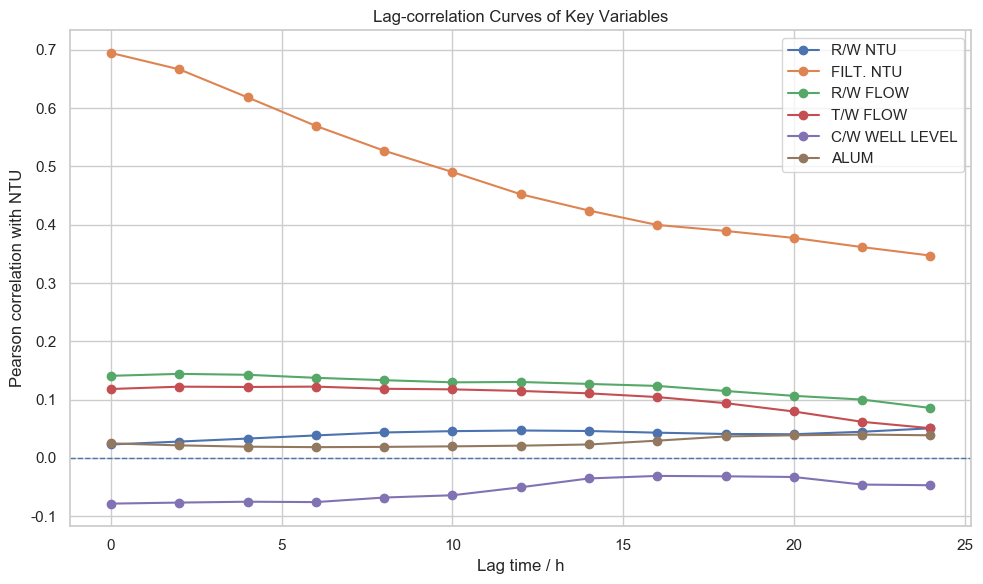

Saved: outputs/problem1/lag_correlation_curves_key_features.png


In [15]:
selected_plot_features = [
    "R/W NTU",
    "FILT. NTU",
    "R/W FLOW",
    "T/W FLOW",
    "C/W WELL LEVEL",
    "ALUM"
]

selected_plot_features = [f for f in selected_plot_features if f in candidate_features]

plt.figure(figsize=(10, 6))

for feature in selected_plot_features:
    temp = lag_corr_df[lag_corr_df["feature"] == feature]
    plt.plot(
        temp["lag_hours"],
        temp["pearson_corr"],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag time / h")
plt.ylabel("Pearson correlation with NTU")
plt.title("Lag-correlation Curves of Key Variables")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "lag_correlation_curves_key_features.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

## 15. 滞后相关性热力图

热力图用于同时展示所有候选变量在不同滞后时间下与 `NTU` 的 Pearson 相关性。颜色越深表示相关性绝对值越大，正负号表示相关方向。

该图主要用于辅助判断变量的滞后模式。例如，若某变量在 `lag0` 或 `lag1` 附近相关性最强，则说明其影响更偏向同期或短期；若某变量在较长滞后下才出现较高相关性，则需要结合水处理过程判断该滞后是否具有合理物理解释。

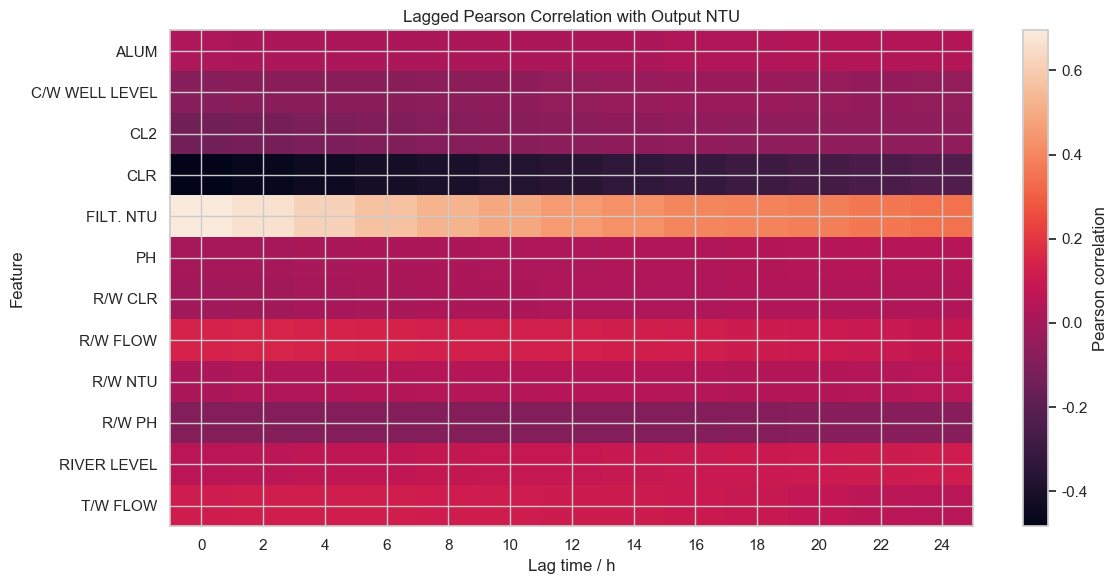

Saved: outputs/problem1/lag_pearson_heatmap.png


In [16]:
heatmap_data = lag_corr_df.pivot(
    index="feature",
    columns="lag_hours",
    values="pearson_corr"
)

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Pearson correlation")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Lag time / h")
plt.ylabel("Feature")
plt.title("Lagged Pearson Correlation with Output NTU")

plt.tight_layout()

heatmap_path = OUTPUT_DIR / "lag_pearson_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print("Saved:", heatmap_path)

### 12.8 滞后相关性分析小结

滞后相关性分析用于判断候选变量是否存在明显的时间延迟关系。结果显示，并非所有变量都具有强滞后相关性，因此后续建模不能机械地将所有变量的高阶滞后项全部纳入模型。

在后续 Selected-lag 模型中，应优先选择同时满足以下条件的特征：

1. 与 `NTU` 的相关性相对较强；
2. 滞后时间具有合理的水处理过程解释；
3. 变量缺失率较低或经过合理处理；
4. 不会造成明显的信息泄漏。

因此，后续模型将基于相关性强度和物理意义，筛选少量合理的滞后特征进入 Random Forest 和 XGBoost，而不是直接使用所有变量的数学最优滞后项。